# Level 2 + Optuna 超參數調優

對 GBM Single Model（目前最佳 AUC=0.7051）做自動超參數搜尋。

**搜尋空間：**
- `n_estimators`: 100–600
- `max_depth`: 2–8
- `learning_rate`: 0.01–0.3
- `subsample`: 0.5–1.0
- `min_samples_leaf`: 5–100
- `max_features`: 0.4–1.0

**目標：** 5-fold Stratified CV AUC 最大化（100 trials，可 overnight）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import roc_auc_score, r2_score, mean_absolute_error
import warnings, time
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 減少雜訊
plt.rcParams['font.size'] = 12
print('準備完成')

準備完成


In [2]:
# ============================================================
# 1. 載入資料 & 前處理
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

DROP_COLS = ['ID', 'LastName', 'FirstName', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

train = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train = train.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)

X_all    = preprocess(train)
y_cls    = train['GaveThisYear'].astype(int)
y_amt    = train['AmtThisYear']
feature_cols = X_all.columns.tolist()

X_train, X_val, y_cls_train, y_cls_val, y_amt_train, y_amt_val = train_test_split(
    X_all, y_cls, y_amt, test_size=0.2, random_state=42, stratify=y_cls
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_all_sc   = scaler.fit_transform(X_all)  # full for CV

print(f'資料準備完成: {X_all.shape}, 特徵數={len(feature_cols)}')
print(f'基準 AUC（GBM default）: 0.7051')

資料準備完成: (100000, 20), 特徵數=20
基準 AUC（GBM default）: 0.7051


In [3]:
# ============================================================
# 2. Optuna：搜尋最佳超參數（預計 20–40 分鐘）
# ============================================================

N_TRIALS = 100
N_FOLDS  = 5

def objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 600),
        'max_depth':       trial.suggest_int('max_depth', 2, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf', 5, 100),
        'max_features':    trial.suggest_float('max_features', 0.4, 1.0),
        'random_state': 42,
    }
    clf = GradientBoostingClassifier(**params)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X_all_sc, y_cls, cv=skf, scoring='roc_auc', n_jobs=-1)
    return aucs.mean()

study = optuna.create_study(direction='maximize', study_name='gbm_auc')

# 先加入現有的 baseline（讓 Optuna 知道從哪裡出發）
study.enqueue_trial({
    'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05,
    'subsample': 0.8, 'min_samples_leaf': 1, 'max_features': 1.0
})

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

best = study.best_params
best_auc = study.best_value

print(f'\n搜尋完成！耗時 {elapsed/60:.1f} 分鐘')
print(f'最佳 CV AUC: {best_auc:.4f}  （基準: 0.7051）')
print(f'提升: {best_auc - 0.7051:+.4f}')
print(f'\n最佳超參數:')
for k, v in best.items():
    print(f'  {k}: {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


搜尋完成！耗時 57.0 分鐘
最佳 CV AUC: 0.7084  （基準: 0.7051）
提升: +0.0033

最佳超參數:
  n_estimators: 375
  max_depth: 6
  learning_rate: 0.012891337856562187
  subsample: 0.6042231005181623
  min_samples_leaf: 45
  max_features: 0.9198281472416061


最佳模型 驗證結果:
  Holdout AUC:  0.7057  （基準: 0.7051）
  CV AUC:       0.7084
  R² (log):     0.0250  （基準: 0.0155）
  策略效率:     67.4%  （基準: 70.3%）
  聯繫人數:     11,218
  Surplus:      $116,785


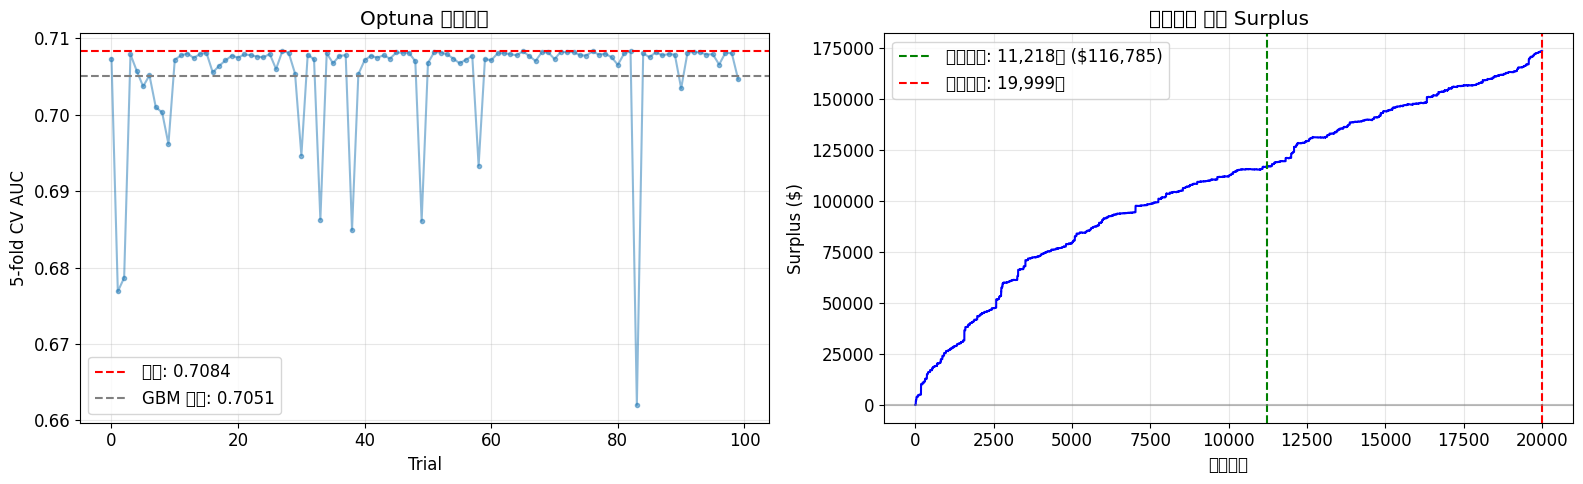

In [4]:
# ============================================================
# 3. 最佳模型：Holdout 驗證 & Uplift 策略
# ============================================================

COST_SCHEDULE = [(60_000, 5), (np.inf, 25)]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier; prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit: return cost
    return schedule[-1][1]

# 用最佳超參數訓練
clf_best = GradientBoostingClassifier(**best, random_state=42)
clf_best.fit(X_train_sc, y_cls_train)
auc_holdout = roc_auc_score(y_cls_val, clf_best.predict_proba(X_val_sc)[:, 1])

# 回歸模型（超參數也套用，但保持原本設定）
donor_mask_train = y_amt_train > 0
donor_mask_val   = y_amt_val   > 0
scaler_reg = StandardScaler()
X_donors_train_sc = scaler_reg.fit_transform(X_train[donor_mask_train])
X_donors_val_sc   = scaler_reg.transform(X_val[donor_mask_val])

reg_best = GradientBoostingRegressor(
    n_estimators=best['n_estimators'], max_depth=best['max_depth'],
    learning_rate=best['learning_rate'], subsample=best['subsample'],
    min_samples_leaf=best['min_samples_leaf'], random_state=42
)
reg_best.fit(X_donors_train_sc, np.log1p(y_amt_train[donor_mask_train]))
r2_log = r2_score(np.log1p(y_amt_val[donor_mask_val]),
                  reg_best.predict(X_donors_val_sc))

# Uplift
def score_with_contact(X_df, contact_val, clf, scaler_cls, reg, scaler_reg):
    Xc = X_df.copy(); Xc['Contact'] = contact_val
    Xc_sc = scaler_cls.transform(Xc)
    P = clf.predict_proba(Xc_sc)[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(Xc))).clip(min=0)
    return P, E, P * E

P1v, E1v, EV1v = score_with_contact(X_val, 1, clf_best, scaler, reg_best, scaler_reg)
P0v, E0v, EV0v = score_with_contact(X_val, 0, clf_best, scaler, reg_best, scaler_reg)
uplift_v = EV1v - EV0v

vdf = pd.DataFrame({'uplift': uplift_v, 'actual_amt': y_amt_val.values,
                    'EV_nocontact': EV0v}).sort_values('uplift', ascending=False).reset_index(drop=True)
vdf['rank']          = range(1, len(vdf)+1)
vdf['marginal_cost'] = vdf['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
vdf['cum_donation']  = vdf['actual_amt'].cumsum()
vdf['cum_cost']      = vdf['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
vdf['cum_surplus']   = vdf['cum_donation'] - vdf['cum_cost']

our_n        = (vdf['uplift'] > vdf['marginal_cost']).sum()
our_surplus  = vdf.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n       = vdf['cum_surplus'].idxmax() + 1
best_surplus = vdf['cum_surplus'].max()

print(f'最佳模型 驗證結果:')
print(f'  Holdout AUC:  {auc_holdout:.4f}  （基準: 0.7051）')
print(f'  CV AUC:       {best_auc:.4f}')
print(f'  R² (log):     {r2_log:.4f}  （基準: 0.0155）')
print(f'  策略效率:     {our_surplus/best_surplus:.1%}  （基準: 70.3%）')
print(f'  聯繫人數:     {our_n:,}')
print(f'  Surplus:      ${our_surplus:,.0f}')

# Optuna 搜尋歷程
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
trials_df = study.trials_dataframe()

ax = axes[0]
ax.plot(trials_df['number'], trials_df['value'], 'o-', ms=3, alpha=0.5)
ax.axhline(best_auc, color='red', ls='--', label=f'最佳: {best_auc:.4f}')
ax.axhline(0.7051,   color='gray', ls='--', label='GBM 基準: 0.7051')
ax.set_xlabel('Trial'); ax.set_ylabel('5-fold CV AUC')
ax.set_title('Optuna 搜尋歷程'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(vdf['rank'], vdf['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'最佳模型: {our_n:,}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'理論最佳: {best_n:,}人')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數'); ax.set_ylabel('Surplus ($)')
ax.set_title('最佳模型 累積 Surplus'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# ============================================================
# 4. 全量重訓練 → SCOREDATA 評分 & 匯出
# ============================================================
# 只在 AUC 有顯著提升（>0.71）時才值得上傳

print(f'AUC 提升: {auc_holdout - 0.7051:+.4f}')
if auc_holdout <= 0.7051:
    print('⚠️  AUC 沒有提升，建議不上傳，維持現有最佳結果')
else:
    print('✅  AUC 有提升，繼續評分並匯出')

# 不管結果如何都先跑完，方便比較
scaler_full = StandardScaler()
X_all_sc_full = scaler_full.fit_transform(X_all)

clf_full = GradientBoostingClassifier(**best, random_state=42)
clf_full.fit(X_all_sc_full, y_cls)
print('分類模型（全資料）完成')

donor_mask_all = y_amt > 0
scaler_reg_full = StandardScaler()
reg_full = GradientBoostingRegressor(
    n_estimators=best['n_estimators'], max_depth=best['max_depth'],
    learning_rate=best['learning_rate'], subsample=best['subsample'],
    min_samples_leaf=best['min_samples_leaf'], random_state=42
)
reg_full.fit(scaler_reg_full.fit_transform(X_all[donor_mask_all]), np.log1p(y_amt[donor_mask_all]))
print(f'回歸模型（全資料）完成')

score_c  = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')
score_nc = load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv')
score_ids = score_c['ID'].copy()

def score_sd(df, clf, scaler_cls, reg, scaler_reg, feature_cols):
    X = preprocess(df, feature_cols=feature_cols)
    P = clf.predict_proba(scaler_cls.transform(X))[:, 1]
    E = np.expm1(reg.predict(scaler_reg.transform(X))).clip(min=0)
    return P, E, P * E

P1s, E1s, EV1s = score_sd(score_c,  clf_full, scaler_full, reg_full, scaler_reg_full, feature_cols)
P0s, E0s, EV0s = score_sd(score_nc, clf_full, scaler_full, reg_full, scaler_reg_full, feature_cols)
uplift_s = EV1s - EV0s

SURE_THING_THRESHOLD = 5
score_df = pd.DataFrame({
    'ID': score_ids.values, 'EV_contact': EV1s, 'EV_nocontact': EV0s, 'uplift': uplift_s,
}).sort_values('uplift', ascending=False).reset_index(drop=True)
score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify(row):
    if row['uplift'] > row['marginal_cost']:                                  return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= 0:  return 'Sure Thing'
    elif row['uplift'] < 0:                                                   return 'Sleeping Dog'
    else:                                                                      return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify, axis=1)
contact = score_df[score_df['quadrant'] == 'Persuadable']
n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print(f'\n四象限分布:')
print(score_df['quadrant'].value_counts())
print(f'\n聯繫: {n_contact:,} 人, 預估成本 ${total_cost:,.0f}')
print(f'比較 GBM 基準: 53,277 人')

import os; os.makedirs('output', exist_ok=True)
output_path = 'output/level2_optuna_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 → {output_path}')

AUC 提升: +0.0006
✅  AUC 有提升，繼續評分並匯出
分類模型（全資料）完成
回歸模型（全資料）完成

四象限分布:
quadrant
Persuadable     52243
Lost Cause      21048
Sure Thing      16179
Sleeping Dog    10530
Name: count, dtype: int64

聯繫: 52,243 人, 預估成本 $261,215
比較 GBM 基準: 53,277 人

已匯出 → output/level2_optuna_contact_list.csv
